# 15장 RNN과 CNN을 사용한 시퀀스 처리

# 개요

### RNN (순환 신경망)

> 시계열 데이터를 분석하고 과거 패턴을 학습하여 미래를 예측하는데 사용되는 신경망
> 이전 타임 스텝의 출력을 현재 타임 스텝의 입력을 사용하는 `순환 연결`을 특징으로함

- `타임스텝` : 시퀀스 데이터를 처리하는 각 순간

#### 특징
- `고정 길이 입력`와 더불어 `임의 길이 시퀀스`를 다룰 수 있음

In [45]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

import sys
# 코랩의 경우 나눔 폰트를 설치합니다.
if 'google.colab' in sys.modules:
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

# 나눔 폰트를 사용합니다.
import matplotlib

matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

# 1. 순환 뉴런과 순환 층

## 개요

### 순환 신경망 (RNN)
- 피드 포워드 층과 유사
- 단, `순환 연결`을 가짐

### 타임스텝
- 시퀀스를 처리하는 순간
    - 프레임 이라고도 불림

- 현재 타임 스텝의 처리(예: 출력 $\text{y(t)}$ 및 히든 상태 $\text{h(t)}$)는 현재 입력 $\text{x(t)}$뿐만 아니라 **이전 타임 스텝의 히든 상태 $\text{h(t-1)}$**에 의존
  - 첫번째 타임 스텝에서는 이전 출력을 `0`으로 가정

### 네트워크 전개
  - RNN이 여러 타임스텝에 걸쳐 작동되는 것을 시각화 한 형태
  - RNN이 임의 길이의 시퀀스를 다룰 수 있게됨

### 순환 뉴런의 가중치
  - 두 벌의 가중치를 가짐
  - `현재 타임 스텝의 입력` : $\text{x(t)}$에 대한 가중치 $\text{W}_\text{x}$
  - `이전 타임 스텝의 입력`  : $\text{y(t-1)}$에 대한 가중치 $\text{W}_\text{y}$
    - 출력 계산 : 편향 $\text{b}$와 활성화 함수 $\phi$ 로 계산

- 식 표현

- $\hat{y}_{(t)} = \phi (\textrm{W}_x^T \cdot \textrm{x}_{(t)} + \textrm{W}_{\hat{y}}^T \cdot \hat{\textrm{y}}_{(t-1)} + b)$
  - $b$ : 편향
  - $\phi(\cdot)$ : 활성화 함수
  - $\text{W}_\text{x}$ : 현재 타임 스텝의 입력
  - $\text{W}_\text{y}$ : 이전 타입 스텝의 출력

## 메모리 셀

### 정의
> 타임스텝 $t$에서 순환 뉴런의 출력은 이전 타임 스텝의 모든 입력에 대한 일종의 `기억`

### 특징
- 네트워크에 걸쳐 어떤 상태를 보존하는 신경망의 구성요소
- 하나의 순환 뉴런 혹은 층은 짧은 패턴(약 10스텝 정도)만 학습

### 원리
- 타임스텝 $t$에서 셀의 히든 상태 ($\text{h(t)}$)는 해당 타임 스텝의 입력과 이전 타임 스텝의 상태에 대한 함수
  - $\text{h(t)=f(x(t), h}_{(t-1)})$
    - 현재 입력 $f(x(t)$
    - 이전 상태 함수 $h_{(t-1)}$

## 입력과 출력 시퀀스

### 시퀀스-투-시퀀스 네트워크
- 하나의 입력으로 시계열 데이터를 예측하는데 사용

### 시퀀스-투-벡터 네트워크
- 시퀀스를 네트워크에 주입
- 마지막을 제외한 모든 출력 무시
- 하나의 벡터만 출력
  - 예시 ) 이미지에 대한 캡션 생성

### 벡터-투-시퀀스 네트워크
- 단일 입력 벡터를 주입
- 하나의 시퀀스 출력
  - 예시 ) 이미지 캡션 생성

### 인코더-디코더
- 인코더와 디코더를 연결한 구조
    - `인코더` : 시퀀스-투-벡터 네트워크
      - 예시 ) 문장을 벡터로 표현
    - `디코더` : 벡터-투-시퀀스 네트워크
      - 예시 ) 벡터를 다른 문장으로 번역

- 디코더의 마지막 타임스텝의 출력이 다음 타임 스텝의 입력으로 들어감

----

# 2. RNN 훈련

## BPTT

### 정의

> Backpropagation Throgh Time
> 타임스텝 별로 네트워크를 전개하고 오차 역전파를 시간으로 연결하는 방식


### 프로세스

#### 1단계 : 네트워크 전개
- RNN을 타임 스텝별로 전개
  - 타임스텝마다 동일한 뉴런이 시간 축을 따라 펼쳐짐

#### 2단계 : 손실 평가
- 전개된 네트워크의 출력 시퀀스를 평가
  - 손실 함수는 출력 시퀀스의 일부 혹은 전체에 적용

#### 3단계 : 그레디언트 역전파
- 손실함수의 그레디언트가 전개된 네트워크를 통해 역방향으로 전파
  - 현재 출력에 대한 그레디언트 + 이전 타임스텝에 대한 출력 그레디언트

#### 4단계 : 그레디언트 합산 및 파라미터 업데이트
- 각 타임스텝에서 동일한 파라미터가 사용
  - 역전파 과정에서 그레디언트가 여러번 더해짐
- 계산 완료 후 모든 그레디언트 합산
- 파라미터 업데이트에 합산된 그레디언트 사용

----

# 3. 시계열 예측

## 개요

### 시계열 (Time Series)
- `시계열` : 일정한 간격의 타임스텝 값을 가진 데이터

### 종류
- `단변량 시계열` : 단일변수로 구성된 시계열
- `다변량 시계열` : 여러 변수를 포함한 시계열

### 시계열 응용
- 미래 예측
- 대치 : 누락된 값을 대치
- 분류 : 시계열 데이터를 특정 범주로 분류
- 이상치 탐지 : 비정상적인 데이터 패턴 탐지

### 주요 개념
- 계절성 : 일정 주기로 정기적으로 반복되는 패턴

- 트렌드 : 시간에 따라 변화하는 장기적인 경향

- 자기 상관 시계열 : 시간이 지연된 자기 자신과 상관관계를 가지는 시계열

- 정상 시계열 : 통계적인 속성이 시간에 따라 일정한 시계열
  - ARMA 모델 등에서는 정상 시계열에서 잘 작동

- 비정상 시계열의 처리
  - 비정상 시계열을 정상 시계열로 변환 하는것이 중요할 수도 있음
  - `차분(Differencing)` : 시계열에서 트렌드와 계절성을 제거하여 `정상 시계열`로 만드는 기법
  - $d$차 차분은 시계열의 $d$차 도함수 계산하여 $d$차 다항식 트렌드를 제거

  - 평균 절대 비율 오차 (MAPE) : 평균 절대 오차 / 타깃 값
    - 예측을 평가하는데 사용되는 지표

## 시카고 버스/열차 데이터를 이용한 예측

- 데이터 파일 다운로드

In [46]:
import tensorflow as tf

### 데이터 파일을 받음
tf.keras.utils.get_file(
    "ridership.tgz",
    "https://github.com/ageron/data/raw/main/ridership.tgz",
    cache_dir=".",
    extract=True
)

'./datasets/ridership_extracted'

- 데이터 로드

In [47]:
import pandas as pd
from pathlib import Path

path = Path("datasets/ridership_extracted/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)
# 중복된 월 제거 (2011-10와 2014-07)
df = df.drop_duplicates()

### 데이터 확인
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


- 3개월치 시각화를 통한 트렌드 파악

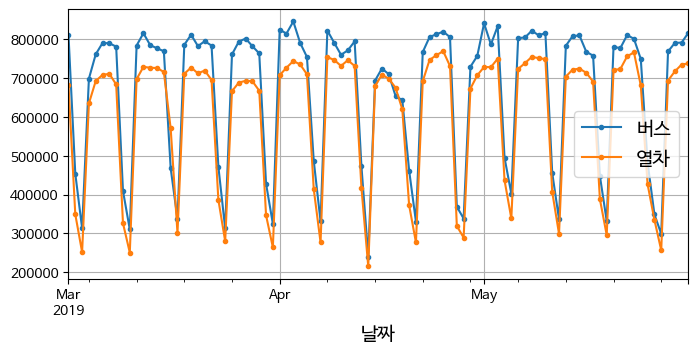

In [48]:
import matplotlib.pyplot as plt

df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.legend(["버스", "열차"]);
plt.xlabel("날짜")
plt.show()

- 차분 그래프 추가
  - 1주일(7일)을 뺀 데이터 추가
  - 이를 통한 트렌드 파악 가능
  - 자기상관 시계열임 확인

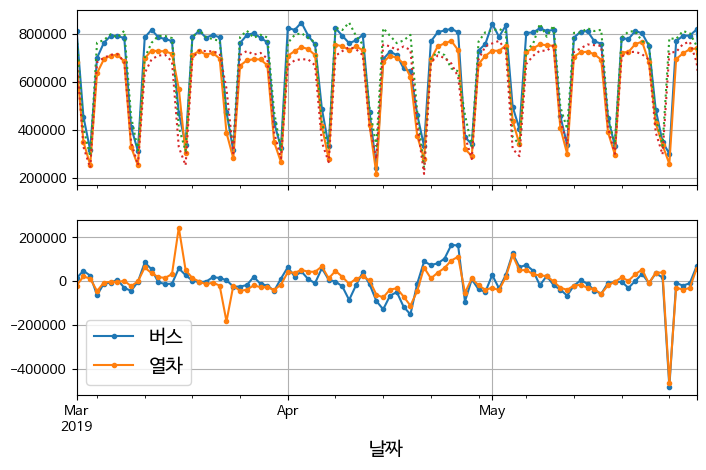

In [49]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker=".")  # 원본 시계열
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")  # 지연
diff_7.plot(ax=axs[1], grid=True, marker=".")  # 7일 차분 시계열
axs[1].legend(["버스", "열차"])
axs[1].set_xlabel("날짜")
axs[0].set_ylim([170_000, 900_000])
plt.show()

- 5월말에 차이가 심함
  - 공휴일이었는지 확인 : 맞음

In [50]:
list(df.loc["2019-05-25":"2019-05-27"]["day_type"])

['A', 'U', 'U']

- MAE(평균 절댓값 오차)를 구하여 대략적인 아이디 얻기

In [51]:
diff_7.abs().mean()

,0
bus,43915.608696
rail,42143.271739


- 평균 절대 오차(MAPE)
  - 예측 오차 / 타깃 값

In [52]:
targets = df[["bus", "rail"]]["2019-03":"2019-05"]
(diff_7 / targets).abs().mean()

,0
bus,0.082938
rail,0.089948


- 2001년 / 2019년 데이터 시각화
  - 연간 계절성이 있는 것으로 보임

/tmp/ipython-input-1810236529.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample('M').mean(numeric_only=True)


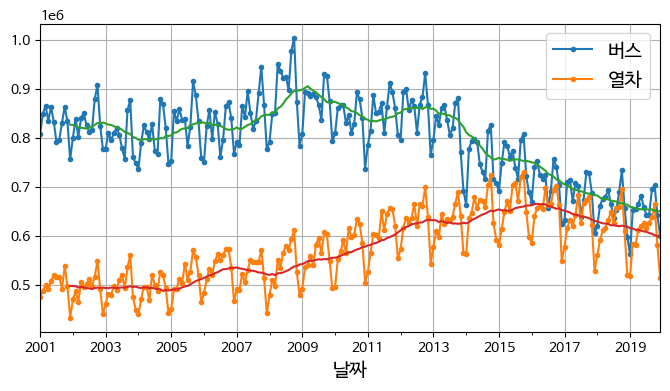

In [53]:
period = slice("2001", "2019")

### 월별 평균
df_monthly = df.resample('M').mean(numeric_only=True)
rolling_average_12_months = df_monthly[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(8, 4))
df_monthly[period].plot(ax=ax, marker=".")
rolling_average_12_months.plot(ax=ax, grid=True, legend=False)
ax.legend(["버스", "열차"]);
ax.set_xlabel('날짜')

plt.show()

- 12개월 차분
  - 장기 트렌드를 없앰

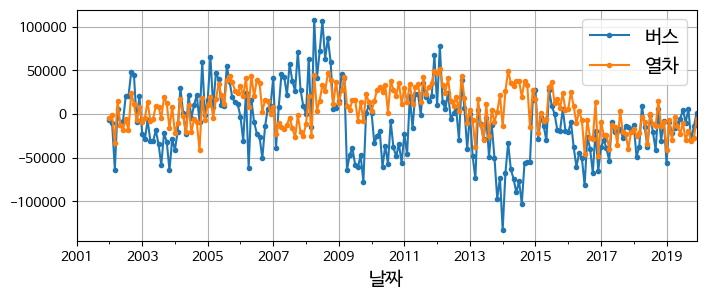

In [54]:
df_monthly.diff(12)[period].plot(grid=True, marker=".", figsize=(8, 3))
plt.legend(["버스", "열차"])
plt.xlabel("날짜")
plt.show()

## ARMA 모델

### 정의
> Autoregressive Moving Average Model
> 이전 값과 이전 예측 오차의 가중치 합을 사용하여 예측하는 모델

- ARMA 모델 식

<br/>

$$
\hat{y}_{(i)}=∑_{i=1}^p \alpha_i y_{(t-1)} + ∑_{i=1}^q \theta_i \varepsilon _{(t-1)} \\
\text{이때,  } \varepsilon _{(t)} ={y}_{(i)} - \hat{y}_{(i)}
$$

- $\hat{y}_{(i)}$ : t시점 모델 예측
- ${y}_{(i)}$ : t시점 시계열 값
- $∑_{i=1}^p \alpha_i y_{(t-1)}$
  - 지난 p개의 값의 가중치 합
  - 얼마나 먼 과거까지 바라볼 것인지
  - 자기 상관 부분
  - $\alpha_i$ : 학습되는 가중치

- $ ∑_{i=1}^q \theta_i \varepsilon _{(t-1)}$
  - 지난 q개의 예측오차의 가중치 합
  - $\varepsilon _{(t-)}$ : 예측오차
  - $\theta$ : 학습되는 가중치
  - 이동평균 부분
  
### 특징
- 정상 시계열을 가정

### 종류

#### ARIMA 모델
- ARMA에 `차분` 개념을 추가
- `비정상 시계열`을 다룰 수 있음
##### 파라미터
  - $d$ : 차분
  - $p$ : 자기회귀
  - $q$ : 이동평균

#### SARIMA 모델
- ARIMA 모델에 계절성 파라미터 추가
- 계절성 패턴을 효과적으로 모델링 가능
##### 파라미터
  - $d$ : 차분
  - $p$ : 자기회귀
  - $q$ : 이동평균
  - $s$ : 계절성 패턴의 기간

### 모델 평가 지표
- 평균 절대 오차 백분율 (MAPE)


- 예제 : ARIMA 구현
  - statsmodels에 구현

In [55]:
import sys
if "google.colab" in sys.modules:
    %pip install -q -U statsmodels

In [56]:
from statsmodels.tsa.arima.model import ARIMA

origin, today = "2019-01-01", "2019-05-31"
rail_series = df.loc[origin:today]["rail"].asfreq("D")
model = ARIMA(rail_series,
              order=(1, 0, 0),
              seasonal_order=(0, 1, 1, 7))
model = model.fit()
y_pred = model.forecast()

print("y_pred[0] : ", y_pred[0])

y_pred[0] :  427758.6262875742


/tmp/ipython-input-1707085869.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("y_pred[0] : ", y_pred[0])


- MAE 계산

In [57]:
origin, start_date, end_date = "2019-01-01", "2019-03-01", "2019-05-31"
time_period = pd.date_range(start_date, end_date)
rail_series = df.loc[origin:end_date]["rail"].asfreq("D")
y_preds = []
for today in time_period.shift(-1):
    model = ARIMA(rail_series[origin:today],
                  order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, 7))
    model = model.fit()
    y_pred = model.forecast().iloc[0]
    y_preds.append(y_pred)

y_preds = pd.Series(y_preds, index=time_period)
mae = (y_preds - rail_series[time_period]).abs().mean()

print("mae : ",mae)

mae :  32040.72009292839


## 머신러닝 모델을 위한 데이터 준비

- `tf.keras.utils.timeseries_dataset_from_array()` : 시계열을 입력받으면 원하는 길이의 모든 윈도와 타깃을 담은 `Dataset`으로 만듦
- 단순예측과 SARIMA 모델을 이용하여 시계열 예측

### 기본 선형 모델
- 목표 : 과거 8주 데이터를 기반으로 내일의 승객 수 예측

In [58]:
import tensorflow as tf

my_series = [0, 1, 2, 3, 4, 5]
my_dataset = tf.keras.utils.timeseries_dataset_from_array(
    my_series,
    ### 네번째 원소부터 타겟
    targets=my_series[3:],
    sequence_length=3,
    batch_size=2
)
print("list(my_dataset) : ",list(my_dataset))

list(my_dataset) :  [(<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[0, 1, 2],
       [1, 2, 3]], dtype=int32)>, <tf.Tensor: shape=(2,), dtype=int32, numpy=array([3, 4], dtype=int32)>), (<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[2, 3, 4]], dtype=int32)>, <tf.Tensor: shape=(1,), dtype=int32, numpy=array([5], dtype=int32)>)]


- 데이터셋의 샘플은 길이가 3인 윈도와 타깃값으로 구성
- `windo()` 데이터셋의 데이터셋 반환 가능
  - `윈도` : 시계열 데이터를 모델의 입력으로 사용하기 위해 일정한 길이로 잘라낸 데이터 세그먼트
    - 삭제 : `window(drop_remainder=True)` 가장 작은 윈도우 삭제


In [59]:
for window_dataset in tf.data.Dataset.range(6).window(4, shift=1):
    for element in window_dataset:
        print(f"{element}", end=" ")
    print()

0 1 2 3 
1 2 3 4 
2 3 4 5 
3 4 5 
4 5 
5 


-  `flat_map()` :  중첩된 데이터셋을 플랫 데이터셋 변환

In [60]:
dataset = tf.data.Dataset.range(6).window(4, shift=1, drop_remainder=True)
dataset = dataset.flat_map(lambda window_dataset: window_dataset.batch(4))
for window_tensor in dataset:
    print(f"{window_tensor}")

[0 1 2 3]
[1 2 3 4]
[2 3 4 5]


- 윈도 추출용 헬퍼함수 생성

In [61]:
def to_windows(dataset, length):
    dataset = dataset.window(length, shift=1, drop_remainder=True)
    return dataset.flat_map(lambda window_ds: window_ds.batch(length))

- `map()` 매서드로 윈도를 입력과 타깃으로 나눔
- 만들어진 윈도의 크기를 2인 배치로 만듦

In [62]:
dataset = to_windows(tf.data.Dataset.range(6), 4)
dataset = dataset.map(lambda window: (window[:-1], window[-1]))
list(dataset.batch(2))

[(<tf.Tensor: shape=(2, 3), dtype=int64, numpy=
  array([[0, 1, 2],
         [1, 2, 3]])>,
  <tf.Tensor: shape=(2,), dtype=int64, numpy=array([3, 4])>),
 (<tf.Tensor: shape=(1, 3), dtype=int64, numpy=array([[2, 3, 4]])>,
  <tf.Tensor: shape=(1,), dtype=int64, numpy=array([5])>)]

- 훈련세트 분류
  - 기본 가중치 초기화 및 학습률을 잘 작동시키기 위해 값이 0~1 사이가 되도록 백만으로 나눔

In [63]:
rail_train = df["rail"]["2016-01":"2018-12"] / 1e6
rail_valid = df["rail"]["2019-01":"2019-05"] / 1e6
rail_test = df["rail"]["2019-06":] / 1e6

- `timeseries_dataset_from_array()` 로 훈련/검증/데이터 세트를 `dataset` 변환
  -`shuffle=True` : 샘플의 독립 동일 분포 가정을  위해 셔플링

In [64]:
seq_length = 56
tf.random.set_seed(42)

train_ds = tf.keras.utils.timeseries_dataset_from_array(
    rail_train.to_numpy(),
    targets=rail_train[seq_length:],
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    rail_valid.to_numpy(),
    targets=rail_valid[seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

## 선형 모델을 통한 예측

- 손실 : 후버 손실
- 제약 : 조기 종료
- 예측 : 37,866

In [65]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[seq_length])
])
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_mae", patience=50, restore_best_weights=True)
opt = tf.keras.optimizers.SGD(learning_rate=0.02, momentum=0.9)
model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])
history = model.fit(train_ds, validation_data=valid_ds, epochs=500,
                    callbacks=[early_stopping_cb])

Epoch 1/500


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0632 - mae: 0.2883 - val_loss: 0.0168 - val_mae: 0.1523
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0146 - mae: 0.1339 - val_loss: 0.0092 - val_mae: 0.1036
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0106 - mae: 0.1103 - val_loss: 0.0080 - val_mae: 0.0944
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0085 - mae: 0.0976 - val_loss: 0.0073 - val_mae: 0.0897
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0080 - mae: 0.0943 - val_loss: 0.0065 - val_mae: 0.0825
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0074 - mae: 0.0887 - val_loss: 0.0073 - val_mae: 0.0915
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0074 - mae: 0.0884 - val_loss: 0.0056 - val_mae: 0.0756
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0057 - mae: 0.0781 - val_loss: 0.0070 - val_mae: 0.0906
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0072 - 

- 모델 평가

In [66]:
valid_loss, valid_mae = model.evaluate(valid_ds)
valid_mae * 1e6

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0017 - mae: 0.0360 


36006.29419088364

## 간단한 RNN으로 얘측
- 3D 입력을 받음
  - [batch_size, time_step, dimensionality]

  - `demensionality`
    - 단변량 시계열 : 1
    - 다변량 시계열 : 차원의 수

- 시퀀스-투-벡터 모델 이용
  - 문제
    - 순환 뉴런만 가지고 있음 - RNN의 기억력이 한정적임
    - 값이 0\~1.4까지 값인데 활성화 함수가 `tanh`함수(-1\~+1) 를 사용

  - 해결 방안
    - 순환 층 위에 출력 뉴런이 하나이고 활성화 함수가 없는 `밀집층` 추가

In [67]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(1, input_shape=[None, 1])
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


- 학습 / 평가 유틸리티 함수

In [68]:
def fit_and_evaluate(model, train_set, valid_set, learning_rate, epochs=500):
    early_stopping_cb = tf.keras.callbacks.EarlyStopping(
        monitor="val_mae", patience=50, restore_best_weights=True)
    opt = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])
    history = model.fit(train_set, validation_data=valid_set, epochs=epochs,
                        callbacks=[early_stopping_cb])
    valid_loss, valid_mae = model.evaluate(valid_set)
    return valid_mae * 1e6

In [69]:
fit_and_evaluate(model, train_ds, valid_ds, learning_rate=0.02)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.9017 - mae: 1.3678 - val_loss: 0.0616 - val_mae: 0.3007
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0602 - mae: 0.2905 - val_loss: 0.0471 - val_mae: 0.2461
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0349 - mae: 0.1898 - val_loss: 0.0215 - val_mae: 0.1504
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0213 - mae: 0.1719 - val_loss: 0.0205 - val_mae: 0.1509
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0215 - mae: 0.1734 - val_loss: 0.0199 - val_mae: 0.1471
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0202 - mae: 0.1671 - val_loss: 0.0193 - val_mae: 0.1451
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0199 - mae: 0.1680 - val_loss: 0.0188 - val_mae: 0.1434
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0183 - mae: 0.1605 - val_loss: 0.0182 - val_mae: 0.1429
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0

102780.99775314331

- 활성화 함수 없는 밀집층을 추가한 기본 RNN층

In [70]:
univar_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 1]),
    tf.keras.layers.Dense(1)
])

- 모델 컴파일, 훈련, 평가

In [71]:
fit_and_evaluate(univar_model, train_ds, valid_ds, learning_rate=0.05)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0351 - mae: 0.2073 - val_loss: 0.0031 - val_mae: 0.0582
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0050 - mae: 0.0709 - val_loss: 0.0026 - val_mae: 0.0508
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0037 - mae: 0.0581 - val_loss: 0.0023 - val_mae: 0.0419
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0035 - mae: 0.0554 - val_loss: 0.0019 - val_mae: 0.0354
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0031 - mae: 0.0478 - val_loss: 0.0025 - val_mae: 0.0442
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0038 - mae: 0.0556 - val_loss: 0.0021 - val_mae: 0.0405
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0033 - mae: 0.0512 - val_loss: 0.0033 - val_mae: 0.0580
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0036 - mae: 0.0599 - val_loss: 0.0027 - val_mae: 0.0491
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - lo

30378.23550403118

## 심층 RNN

- 기본 RNN 층을 여러 개 쌓은 것이 `심층 RNN`
- 케라스에서도 `SimpleRNN`층을 여러 개 쌓음

- 예시 : 시퀀스-투-시퀀스층 2개 + 마지막으로 시퀀스-투-벡터층 사용 후 Dense층으로 모델 예측 사용

In [72]:
tf.random.set_seed(42)
deep_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, return_sequences=True, input_shape=[None, 1]),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

- 모델 컴파일, 훈련 및 평가

In [73]:
fit_and_evaluate(deep_model, train_ds, valid_ds, learning_rate=0.01)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - loss: 0.0357 - mae: 0.2000 - val_loss: 0.0037 - val_mae: 0.0658
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0056 - mae: 0.0802 - val_loss: 0.0031 - val_mae: 0.0532
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0057 - mae: 0.0740 - val_loss: 0.0033 - val_mae: 0.0588
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0050 - mae: 0.0665 - val_loss: 0.0023 - val_mae: 0.0406
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0047 - mae: 0.0662 - val_loss: 0.0024 - val_mae: 0.0408
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0045 - mae: 0.0624 - val_loss: 0.0027 - val_mae: 0.0475
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0040 - mae: 0.0577 - val_loss: 0.0024 - val_mae: 0.0411
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0040 - mae: 0.0571 - val_loss: 0.0023 - val_mae: 0.0380
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - l

30025.409534573555

## 다변량 시계열 예측

- 구조를 거의 변경하지 않고 단변량 시계열을 다변량 시계열로 변경 가능

- 예시 : 버스,열차 데이터 입력 - 열차 시계열 예측 + `day_type`추가

- 판다스를 이용해 day_type 추가

In [74]:
# 버스 및 열차 시계열을 모두 입력으로 사용
df_mulvar = df[["bus", "rail"]] / 1e6

# 내일의 유형 추가
df_mulvar["next_day_type"] = df["day_type"].shift(-1)

# 요일 유형을 원-핫 인코딩
df_mulvar = pd.get_dummies(df_mulvar)

- 세트 분리

In [75]:
mulvar_train = df_mulvar["2016-01":"2018-12"]
mulvar_valid = df_mulvar["2019-01":"2019-05"]
mulvar_test = df_mulvar["2019-06":]

- 데이터 셋 만들기

In [76]:
import numpy as np

tf.random.set_seed(42)

train_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    ### 모든열을 입력으로 사용
    mulvar_train.to_numpy(np.float32),
    ### 열차 시계열만 예측
    targets=mulvar_train["rail"][seq_length:],
    sequence_length=seq_length,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_mulvar_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(np.float32),
    targets=mulvar_valid["rail"][seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

- RNN 모델로 생성

In [77]:
tf.random.set_seed(42)

mulvar_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


- 모델 컴파일, 훈련, 평가

In [78]:
fit_and_evaluate(mulvar_model, train_mulvar_ds, valid_mulvar_ds,
                 learning_rate=0.05)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.1173 - mae: 0.3498 - val_loss: 0.0117 - val_mae: 0.1455
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0043 - mae: 0.0710 - val_loss: 0.0041 - val_mae: 0.0816
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0031 - mae: 0.0580 - val_loss: 0.0014 - val_mae: 0.0442
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0017 - mae: 0.0401 - val_loss: 0.0011 - val_mae: 0.0370
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0017 - mae: 0.0396 - val_loss: 6.2090e-04 - val_mae: 0.0256
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0017 - mae: 0.0417 - val_loss: 0.0014 - val_mae: 0.0431
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0018 - mae: 0.0442 - val_loss: 0.0012 - val_mae: 0.0401
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0024 - mae: 0.0544 - val_loss: 0.0012 - val_mae: 0.0409
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step -

22795.76286673546

## 여러 타임스텝 앞 예측

- 방법1. `univar_model` 모델 사용하여 예측 - 입력에 추가

- 방법 2. 한 번에 14개 값을 예측하는 RNN 훈련

- 예시 : 다음 14개 스텝을 예측

### univar_model을 이용한 예측 추가

- 예측 값을 입력 시계열에 덧붙임

In [79]:
import numpy as np

X = rail_valid.to_numpy()[np.newaxis, :seq_length, np.newaxis]
for step_ahead in range(14):
    y_pred_one = univar_model.predict(X)
    X = np.concatenate([X, y_pred_one.reshape(1, 1, 1)], axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


- 그래프 시각화

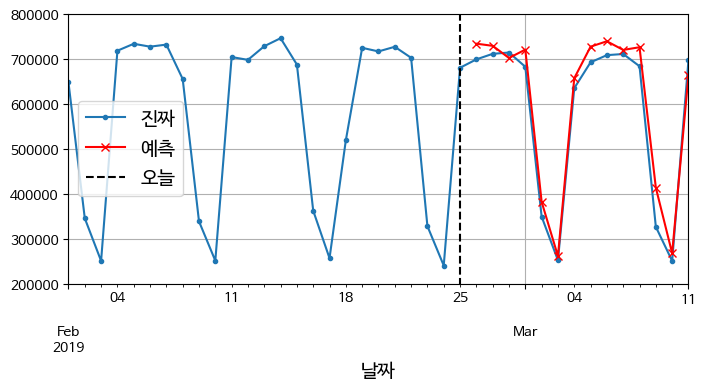

In [80]:
Y_pred = pd.Series(X[0, -14:, 0],
                   index=pd.date_range("2019-02-26", "2019-03-11"))

fig, ax = plt.subplots(figsize=(8, 3.5))
(rail_valid * 1e6)["2019-02-01":"2019-03-11"].plot(
    label="진짜", marker=".", ax=ax)
(Y_pred * 1e6).plot(
    label="예측", grid=True, marker="x", color="r", ax=ax)
ax.vlines("2019-02-25", 0, 1e6, color="k", linestyle="--", label="오늘")
ax.set_ylim([200_000, 800_000])
ax.set_xlabel("날짜")
plt.legend(loc="center left")

plt.show()

### 한 번에 14개 값 예측하는 RNN
- 타깃이 없고 (targets=None), 길이 seq_length+14 인 긴 시퀀스를 가진 데이터셋 생성
- 데이터셋 map()로 시퀀스의 각 배치에 사용자 함수 적용하여 입력과 타깃으로 나눔


In [81]:
tf.random.set_seed(42)

def split_inputs_and_targets(mulvar_series, ahead=14, target_col=1):
    return mulvar_series[:, :-ahead], mulvar_series[:, -ahead:, target_col]

ahead_train_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(np.float32),
    targets=None,
    sequence_length=seq_length + 14,
    batch_size=32,
    shuffle=True,
    seed=42
).map(split_inputs_and_targets)
ahead_valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(np.float32),
    targets=None,
    sequence_length=seq_length + 14,
    batch_size=32
).map(split_inputs_and_targets)

- 출력 층 유닛 개수를 14개로 설정

In [82]:
tf.random.set_seed(42)

ahead_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


- 모델 컴파일, 훈련, 평가

In [83]:
fit_and_evaluate(ahead_model, ahead_train_ds, ahead_valid_ds,
                 learning_rate=0.02)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 0.1828 - mae: 0.4995 - val_loss: 0.0288 - val_mae: 0.1893
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0232 - mae: 0.1665 - val_loss: 0.0142 - val_mae: 0.1266
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0145 - mae: 0.1306 - val_loss: 0.0116 - val_mae: 0.1138
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0126 - mae: 0.1215 - val_loss: 0.0099 - val_mae: 0.1042
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0111 - mae: 0.1129 - val_loss: 0.0087 - val_mae: 0.0979
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0100 - mae: 0.1067 - val_loss: 0.0078 - val_mae: 0.0925
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0091 - mae: 0.1009 - val_loss: 0.0067 - val_mae: 0.0871
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0080 - mae: 0.0950 - val_loss: 0.0061 - val_mae: 0.0837
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - lo

35153.8211107254

- 다음 14개 값 예측

In [84]:
X = mulvar_valid.to_numpy(np.float32)[np.newaxis, :seq_length]  # 크기 [1, 56, 5]
Y_pred = ahead_model.predict(X)  # 크기 [1, 14]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step


## 시퀀스-투-시퀀스 모델로 예측

- 이전 모델이 오차를 누적하지 않 한계가 있음
- 시퀀스 투 시퀀스 모델로 성능 향상 가능
- 14개의 모델을 훈련하지 않고 모든 타임스텝에 다음 14개의 값을 예측하도록 훈련

- 입력을 위한 윈도와 출력을 위한 윈도의 시퀀스를 가져야함
- `to_window()`로 연속적인 윈도의 윈도를 만듦

In [85]:
my_series = tf.data.Dataset.range(7)
dataset = to_windows(to_windows(my_series, 3), 4)
list(dataset)

[<tf.Tensor: shape=(4, 3), dtype=int64, numpy=
 array([[0, 1, 2],
        [1, 2, 3],
        [2, 3, 4],
        [3, 4, 5]])>,
 <tf.Tensor: shape=(4, 3), dtype=int64, numpy=
 array([[1, 2, 3],
        [2, 3, 4],
        [3, 4, 5],
        [4, 5, 6]])>]

- map() 으로 윈도의 윈도를 입력과 타깃으로 나눔

In [86]:
dataset = dataset.map(lambda S: (S[:, 0], S[:, 1:]))
list(dataset)

[(<tf.Tensor: shape=(4,), dtype=int64, numpy=array([0, 1, 2, 3])>,
  <tf.Tensor: shape=(4, 2), dtype=int64, numpy=
  array([[1, 2],
         [2, 3],
         [3, 4],
         [4, 5]])>),
 (<tf.Tensor: shape=(4,), dtype=int64, numpy=array([1, 2, 3, 4])>,
  <tf.Tensor: shape=(4, 2), dtype=int64, numpy=
  array([[2, 3],
         [3, 4],
         [4, 5],
         [5, 6]])>)]

- 데이터셋 준비용 유틸리티 함수 추가
  - 선택적 셔플링 및 배치 처리

In [87]:
def to_seq2seq_dataset(series, seq_length=56, ahead=14, target_col=1,
                       batch_size=32, shuffle=False, seed=None):
    ds = to_windows(tf.data.Dataset.from_tensor_slices(
        series.to_numpy(np.float32)), ahead + 1)
    ds = to_windows(ds, seq_length).map(lambda S: (S[:, 0], S[:, 1:, 1]))
    if shuffle:
        ds = ds.shuffle(8 * batch_size, seed=seed)
    return ds.batch(batch_size)

- 데이터 셋 생성

In [88]:
seq2seq_train = to_seq2seq_dataset(mulvar_train, shuffle=True, seed=42)
seq2seq_valid = to_seq2seq_dataset(mulvar_valid)

- `시퀀스-투-시퀀스` 모델 생성

In [89]:
tf.random.set_seed(42)
seq2seq_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


- 모델 컴파일 및 훈련, 평가

In [90]:
fit_and_evaluate(seq2seq_model, seq2seq_train, seq2seq_valid,
                 learning_rate=0.1)

Epoch 1/500
     33/Unknown 6s 38ms/step - loss: 0.1305 - mae: 0.3762

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - loss: 0.1284 - mae: 0.3723 - val_loss: 0.0138 - val_mae: 0.1293
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0115 - mae: 0.1176 - val_loss: 0.0088 - val_mae: 0.0979
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0078 - mae: 0.0932 - val_loss: 0.0067 - val_mae: 0.0825
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0066 - mae: 0.0834 - val_loss: 0.0060 - val_mae: 0.0761
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0057 - mae: 0.0752 - val_loss: 0.0054 - val_mae: 0.0705
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0051 - mae: 0.0702 - val_loss: 0.0050 - val_mae: 0.0664
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0048 - mae: 0.0674 - val_loss: 0.0053 - val_mae: 0.0698
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0046 - mae: 0.0644 - val_loss: 0.0044 - val_mae: 0.0599
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0044 -

45831.73990249634

- 14일 간 열차 승객 수 예측

In [91]:
X = mulvar_valid.to_numpy(np.float32)[np.newaxis, :seq_length]
y_pred_14 = seq2seq_model.predict(X)[0, -1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step


# 4. 긴 시퀀스 다루기

## 개요
- 긴 시퀀스 RNN의 문제
  - 훈련에 너무 많은 시간이 걸림
  - 훈련이 불안정
  - 입력의 첫부분을 조금씩 잊게죔

## 불안정한 그레디언트 문제 해결

- RNN에서는 `층 정규화`가 가장 훌륭한 선택
  - 배치 차원에 대해 정규화 하는 대신 `특성 차원`에 대해 정규화
  - 단, 타임스텝 마다 동적으로 필요한 통계를 계산 할 수 있음

- 케라스를 이용한 층 정규화
  - `call()` : `inputs` 와 `states` 가 특징
    - `states` : 하나 이상의 텐서를 담은 리스트
      - 이전 타임스텝의 출력과 동일한 하나의 텐서를 담고 있음

- 예시 : `SimpleRNNCell`처럼 작동하는 메모리셀 구현

In [92]:
class LNSimpleRNNCell(tf.keras.layers.Layer):
    def __init__(self, units, activation="tanh", **kwargs):
        super().__init__(**kwargs)
        self.state_size = units
        self.output_size = units
        self.simple_rnn_cell = tf.keras.layers.SimpleRNNCell(units,
                                                             activation=None)
        self.layer_norm = tf.keras.layers.LayerNormalization()
        self.activation = tf.keras.activations.get(activation)

    def call(self, inputs, states):
        outputs, new_states = self.simple_rnn_cell(inputs, states)
        norm_outputs = self.activation(self.layer_norm(outputs))
        return norm_outputs, [norm_outputs]

- tf.keras.layers.RNN층을 이용해 셀의 객체를 전달

In [93]:
tf.random.set_seed(42)

custom_ln_model = tf.keras.Sequential([
    tf.keras.layers.RNN(LNSimpleRNNCell(32), return_sequences=True,
                        input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'ln_simple_rnn_cell', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


- 모델 컴파일, 훈련, 평가

In [94]:
fit_and_evaluate(custom_ln_model, seq2seq_train, seq2seq_valid,
                 learning_rate=0.1, epochs=5)

Epoch 1/5
     33/Unknown 5s 54ms/step - loss: 0.1585 - mae: 0.4089

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 0.1559 - mae: 0.4043 - val_loss: 0.0143 - val_mae: 0.1217
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0105 - mae: 0.1158 - val_loss: 0.0089 - val_mae: 0.0958
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0075 - mae: 0.0918 - val_loss: 0.0073 - val_mae: 0.0855
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0064 - mae: 0.0819 - val_loss: 0.0066 - val_mae: 0.0805
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0059 - mae: 0.0774 - val_loss: 0.0063 - val_mae: 0.0774
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0073 - mae: 0.0820


77442.63112545013

## 단기 기억 문제

### LSTM 셀

> 장단기 메모리 셀
> 훈련이 빠르게 수렴하고 데이터에 있는 장기간 의존성을 감지

#### 원리
- 네트워크가 무엇을 장기 상태에 저장하고, 무엇을 버리고, 무엇을 읽어 들일지를 학습
- LSTM 셀은 두 가지 상태를 가짐:
  - `장기 상태`
    -  이전 타임 스텝의 장기 상태 $c_{t-1}$에 현재 타임 스텝의 정보를 추가/업데이트
    -  중요하지 않은 정보는 삭제
    -  가장 중요한 정보가 저장

    - `단기 상태`
      - 출력($y_t$)과 동일한 정보
      - 모든 타임 스텝에서 출력으로 전달되는 값

- `세 가지 주요 게이트`: LSTM 셀은 이 두 상태를 제어하기 위해 세 가지 종류의 게이트를 사용
  - `삭제 게이트`
      - 장기 상태(c_{t-1})에서 어떤 정보를 삭제할지를 결정
      - 현재 입력($x_t$)과 이전 단기 상태($h_{t-1}$)를 분석하여 0에서 1 사이의 값을 출력
      - 이 값과 장기 상태를 곱하여 삭제할 정보를 제어
  - `입력 게이트`
    -  현재 입력($x_t$)과 이전 단기 상태($h_{t-1}$)를 분석하여 어떤 정보를 장기 상태에 저장할지 결정
    - 새롭게 장기 상태에 추가할 값($g_t$)을 생성
    - 삭제 게이트와 유사하게 0과 1 사이의 값을 출력
    - 새로운 정보의 저장 여부를 제어

  - `출력 게이트`
    -  장기 상태($c_t$)의 어떤 부분이 단기 상태($h_t$)로 출력될지를 결정
        - 현재 입력($x_t$)과 이전 단기 상태($h_{t-1$})를 분석하여 출력할 정보의 가중치를 계산
        - 장기 상태와 결합하여 최종 단기 상태($h_t$) 계산
        
- LSTM은 이러한 게이트 메커니즘을 통해 중요한 입력을 인식
- 장기 상태에 저장하여 필요한 시간 동안 보
- 필요할 때 추론하기 위해 학습

- 케라스에서는 `SimpleRNN`층의 LSTM층 사용

In [97]:
tf.random.set_seed(42)
lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(32, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

- 모델 훈련 및 평가

In [96]:
fit_and_evaluate(lstm_model, seq2seq_train, seq2seq_valid,
                 learning_rate=0.1, epochs=5)

Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.1022 - mae: 0.3605 - val_loss: 0.0187 - val_mae: 0.1680
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0180 - mae: 0.1610 - val_loss: 0.0174 - val_mae: 0.1488
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0158 - mae: 0.1527 - val_loss: 0.0168 - val_mae: 0.1436
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0150 - mae: 0.1490 - val_loss: 0.0162 - val_mae: 0.1404
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0144 - mae: 0.1455 - val_loss: 0.0157 - val_mae: 0.1368
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0164 - mae: 0.1392


136800.91500282288

In [98]:
### GRU

#### 정의
> GRU 셀은 2014년 조경현 등(Kyunghyun Cho et al.)이 제안한 모델로, LSTM 셀의 간소화 버전

#### 목적
- LSTM과 유사하게 일반적인 RNN이 가진 장기적인 의존성 학습의 어려움(단기기억 문제)을 해결하기 위해 고안

#### LSTM과의 주요 차이점 및 원리
- 하나의 상태 벡터
  - LSTM이 장기 상태($c_t$)와 단기 상태($h_t$) 두 가지 상태를 가짐
  - GRU 셀은 두 벡터가 하나의 벡터로 합침

- 통합된 게이트
    - LSTM의 삭제 게이트와 입력 게이트가 하나의 망각 게이트로 통합.
    - 하나의 게이트 제어기가 갱신 게이트(update gate)와 초기화 게이트(reset gate)를 모두 제어
- 출력 게이트 없음
  - LSTM과 달리 GRU 셀에는 별도의 출력 게이트가 없음.
  - 대신 전체 상태 벡터가 매 타임 스텝마다 출력

#### 구조
  - 간소화된 구조 덕분에 GRU 셀은 LSTM 셀보다 매개변수가 적음
  - 학습 속도가 빠를 수 있음

#### 성능
  - GRU 셀은 LSTM 셀과 마찬가지로 RNN의 성공에 크게 기여
  - 긴 시퀀스 데이터에서 장기 패턴을 학습하는 데 매우 유용함.

#### Keras에서의 사용
  - Keras에서는 tf.keras.layers.GRU 층을 사용하여 SimpleRNN이나 LSTM 층을 GRU 층으로 쉽게 바꿀 수 있음.
  - 또한, GRU를 기반으로 사용자 정의 셀을 만들고 tf.keras.layers.GRUCell을 사용할 수도 있음

In [99]:
tf.random.set_seed(42)

gru_model = tf.keras.Sequential([
    tf.keras.layers.GRU(32, return_sequences=True, input_shape=[None, 5]),
    tf.keras.layers.Dense(14)
])

In [101]:
fit_and_evaluate(gru_model, seq2seq_train, seq2seq_valid,
                 learning_rate=0.1, epochs=5)

Epoch 1/5
     31/Unknown 36s 21ms/step - loss: 0.0106 - mae: 0.1180

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


33/33 ━━━━━━━━━━━━━━━━━━━━ 37s 30ms/step - loss: 0.0107 - mae: 0.1181 - val_loss: 0.0117 - val_mae: 0.1146
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0102 - mae: 0.1143 - val_loss: 0.0113 - val_mae: 0.1118
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0097 - mae: 0.1102 - val_loss: 0.0107 - val_mae: 0.1096
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0094 - mae: 0.1082 - val_loss: 0.0104 - val_mae: 0.1078
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0090 - mae: 0.1051 - val_loss: 0.0101 - val_mae: 0.1058
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0110 - mae: 0.1095


105771.55649662018

## 1D 합성곱 층으로 시퀀스 처리

### 특징
- 시계열 데이터에서 다양한 길이 패턴 감지하는데 유용한 방식 중 하나

### 원리
#### 패턴 감지
- 1D 합성곱 층은 2D 합성곱층이 이미지에서 공간적 패턴을 감지하는 것과 유사하게 시퀀스에서 특정 패턴을 감지하는데 뛰어남

#### 작은 커널 사용
- 시퀀스를 따라 이동하는 작은 커널을 사용해 패턴을 탐지
- 각 커널은 특정 패턴 추출

### 주요 매개변수
- `kernel_size` : 커널/필터 사이즈 정의
- `strides` :  스트라이드 / 보폭 정의
- `padding` : 입력 시퀀스의 경계 처리 방식 설정

In [102]:
tf.random.set_seed(42)

conv_rnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(filters=32, kernel_size=4, strides=2,
                           activation="relu", input_shape=[None, 5]),
    tf.keras.layers.GRU(32, return_sequences=True),
    tf.keras.layers.Dense(14)
])

longer_train = to_seq2seq_dataset(mulvar_train, seq_length=112,
                                       shuffle=True, seed=42)
longer_valid = to_seq2seq_dataset(mulvar_valid, seq_length=112)
downsampled_train = longer_train.map(lambda X, Y: (X, Y[:, 3::2]))
downsampled_valid = longer_valid.map(lambda X, Y: (X, Y[:, 3::2]))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## WaveNet
> 1D 합성곱 층을 사용한 대표적인 모델

- 인과적 합성곱과 팽창 비율을 도입하여 매우 긴 시퀀스를 효율적으로 처리

### 팽창 합성곱
- 필터 사이에 0 삽입 = 수용 영역을 넓힘
- 하지만, 매개변수의 수를 늘리지 않음

### 인과적 합성곱
- 미래의 시퀀스를 예측할 때 오직 과거 정보만 사용하도록함

In [103]:
tf.random.set_seed(42)
wavenet_model = tf.keras.Sequential()
wavenet_model.add(tf.keras.layers.InputLayer(input_shape=[None, 5]))
for rate in (1, 2, 4, 8) * 2:
    wavenet_model.add(tf.keras.layers.Conv1D(
        filters=32, kernel_size=2, padding="causal", activation="relu",
        dilation_rate=rate))
wavenet_model.add(tf.keras.layers.Conv1D(filters=14, kernel_size=1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [104]:
fit_and_evaluate(wavenet_model, longer_train, longer_valid,
                 learning_rate=0.1, epochs=5)

Epoch 1/5
     31/Unknown 10s 114ms/step - loss: 0.1299 - mae: 0.4413

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 171ms/step - loss: 0.1280 - mae: 0.4367 - val_loss: 0.0196 - val_mae: 0.1670
Epoch 2/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0175 - mae: 0.1647 - val_loss: 0.0183 - val_mae: 0.1527
Epoch 3/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0156 - mae: 0.1562 - val_loss: 0.0179 - val_mae: 0.1499
Epoch 4/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0151 - mae: 0.1532 - val_loss: 0.0170 - val_mae: 0.1461
Epoch 5/5
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0143 - mae: 0.1478 - val_loss: 0.0156 - val_mae: 0.1381
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0156 - mae: 0.1381


138074.42784309387